In [1]:
import os

dataset_path = "data/raw/PlantVillage"

classes = sorted(os.listdir(dataset_path))
# Remove any hidden files like .DS_Store
classes = [c for c in classes if not c.startswith('.')]

print(f"Total number of classes: {len(classes)}")
print("\nAll classes:")
for i, c in enumerate(classes):
    print(f"  {i+1}. {c}")

Total number of classes: 16

All classes:
  1. Pepper__bell___Bacterial_spot
  2. Pepper__bell___healthy
  3. PlantVillage
  4. Potato___Early_blight
  5. Potato___Late_blight
  6. Potato___healthy
  7. Tomato_Bacterial_spot
  8. Tomato_Early_blight
  9. Tomato_Late_blight
  10. Tomato_Leaf_Mold
  11. Tomato_Septoria_leaf_spot
  12. Tomato_Spider_mites_Two_spotted_spider_mite
  13. Tomato__Target_Spot
  14. Tomato__Tomato_YellowLeaf__Curl_Virus
  15. Tomato__Tomato_mosaic_virus
  16. Tomato_healthy


In [2]:
dataset_path = "data/raw/PlantVillage"

class_counts = {}
for class_name in classes:
    if class_name == "PlantVillage":  # skip the nested folder
        continue
    class_path = os.path.join(dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.JPG', '.png', '.PNG'))]
    class_counts[class_name] = len(images)

total = sum(class_counts.values())
print(f"Total images: {total}\n")
for class_name, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * (count // 100)
    print(f"{count:5d} {bar} {class_name}")

Total images: 20637

 3208 ████████████████████████████████ Tomato__Tomato_YellowLeaf__Curl_Virus
 2127 █████████████████████ Tomato_Bacterial_spot
 1908 ███████████████████ Tomato_Late_blight
 1771 █████████████████ Tomato_Septoria_leaf_spot
 1676 ████████████████ Tomato_Spider_mites_Two_spotted_spider_mite
 1591 ███████████████ Tomato_healthy
 1478 ██████████████ Pepper__bell___healthy
 1404 ██████████████ Tomato__Target_Spot
 1000 ██████████ Potato___Early_blight
 1000 ██████████ Potato___Late_blight
 1000 ██████████ Tomato_Early_blight
  997 █████████ Pepper__bell___Bacterial_spot
  952 █████████ Tomato_Leaf_Mold
  373 ███ Tomato__Tomato_mosaic_virus
  152 █ Potato___healthy


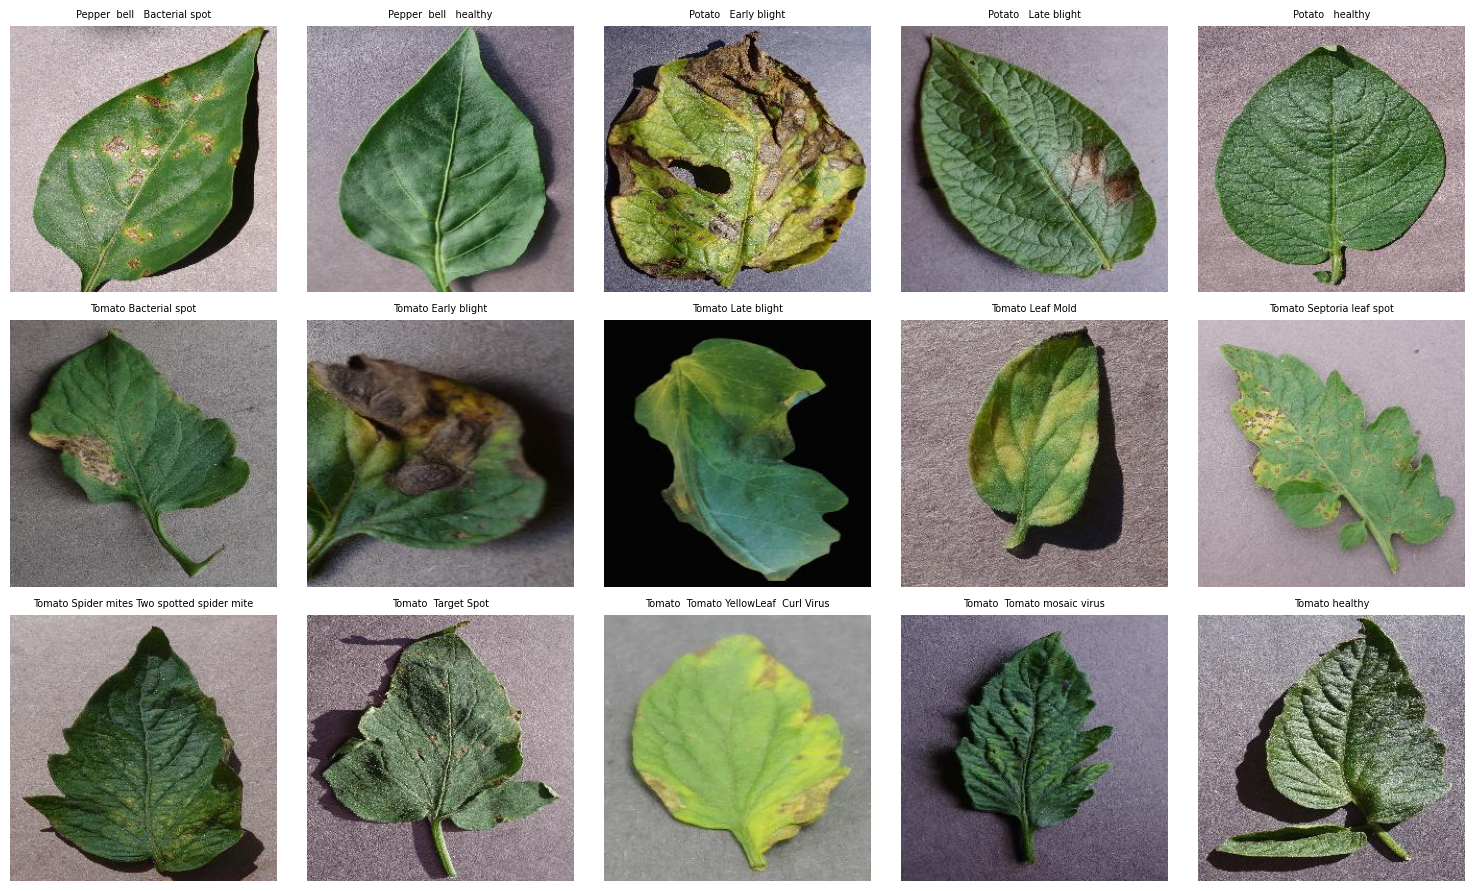

Saved to outputs/class_samples.png


In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, class_name in enumerate(class_counts.keys()):
    class_path = os.path.join(dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.JPG', '.png', '.PNG'))]
    random_image = random.choice(images)
    img = Image.open(os.path.join(class_path, random_image))
    axes[i].imshow(img)
    axes[i].set_title(class_name.replace("_", " "), fontsize=7, wrap=True)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('outputs/class_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/class_samples.png")

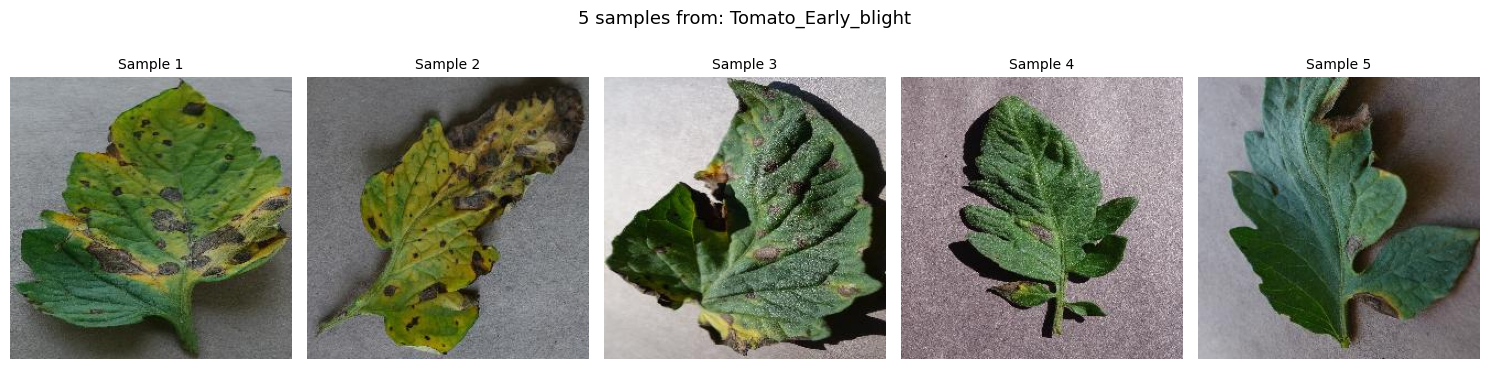

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

class_to_view = "Tomato_Early_blight"
class_path = os.path.join(dataset_path, class_to_view)
images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.JPG', '.png', '.PNG'))]
sample_images = random.sample(images, 5)

for i, img_name in enumerate(sample_images):
    img = Image.open(os.path.join(class_path, img_name))
    axes[i].imshow(img)
    axes[i].set_title(f"Sample {i+1}", fontsize=10)
    axes[i].axis('off')

plt.suptitle(f"5 samples from: {class_to_view}", fontsize=13)
plt.tight_layout()
plt.savefig('outputs/single_class_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
sizes = []
class_path = os.path.join(dataset_path, "Tomato_Early_blight")
images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.JPG', '.png', '.PNG'))]

for img_name in images:
    img = Image.open(os.path.join(class_path, img_name))
    sizes.append(img.size)

unique_sizes = set(sizes)
print(f"Number of unique sizes: {len(unique_sizes)}")
print("\nMost common sizes:")
from collections import Counter
size_counts = Counter(sizes)
for size, count in size_counts.most_common(5):
    print(f"  {size[0]}x{size[1]} pixels — {count} images")

Number of unique sizes: 1

Most common sizes:
  256x256 pixels — 1000 images
